Dataset Shape: (1704, 8)


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4



Missing Values:
 country      0
continent    0
year         0
lifeExp      0
pop          0
gdpPercap    0
iso_alpha    0
iso_num      0
dtype: int64


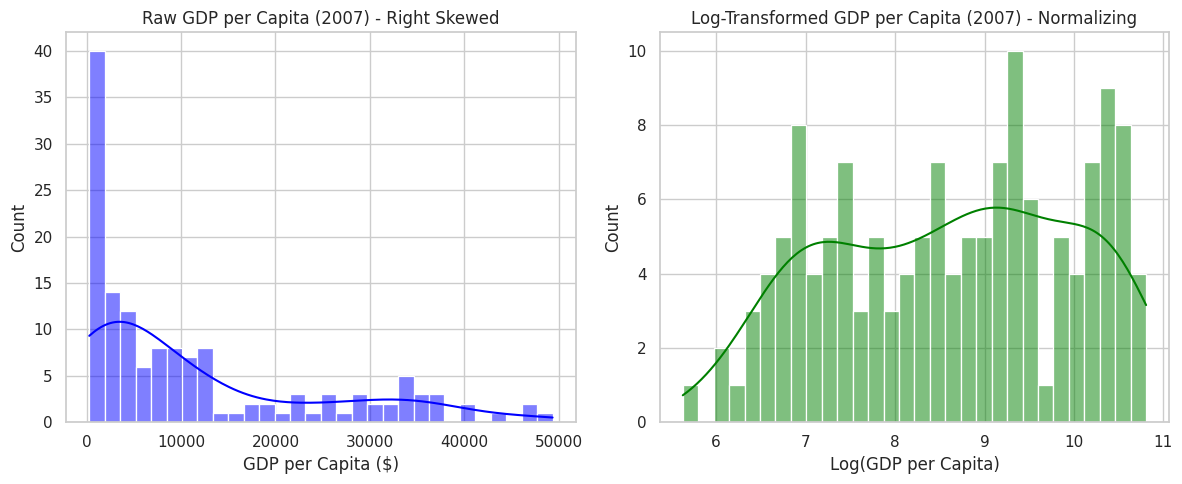

                            OLS Regression Results                            
Dep. Variable:                lifeexp   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     265.2
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           4.12e-34
Time:                        00:13:14   Log-Likelihood:                -479.26
No. Observations:                 142   AIC:                             962.5
Df Residuals:                     140   BIC:                             968.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.9496      3.858      1.283

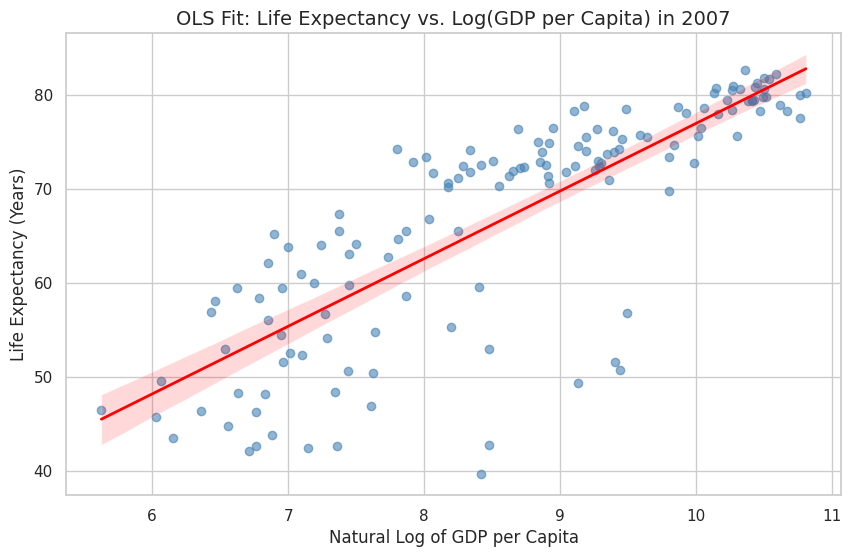

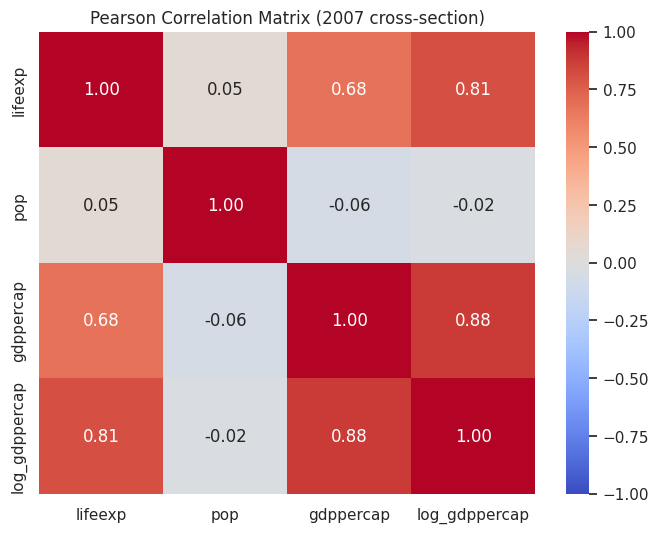

In [3]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import statsmodels.api as sm

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Cell 2: Data Loading & Initial Inspection
# Using plotly's built-in Gapminder dataset for easy access
df = px.data.gapminder()

print("Dataset Shape:", df.shape)
display(df.head())
print("\nMissing Values:\n", df.isnull().sum())

# Cell 3: Data Cleaning & Feature Engineering
# The dataset is clean, but let's simulate professional cleaning steps
# 1. Standardize column names
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

# 2. Econometric Transformation: Log of GDP per capita
# Reason: GDP is right-skewed. Taking the log linearizes its relationship with life expectancy.
df['log_gdppercap'] = np.log(df['gdppercap'])

# Cell 4: Univariate Analysis - Distribution of Wealth
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[df['year'] == 2007]['gdppercap'], bins=30, kde=True, color='blue')
plt.title('Raw GDP per Capita (2007) - Right Skewed')
plt.xlabel('GDP per Capita ($)')

plt.subplot(1, 2, 2)
sns.histplot(df[df['year'] == 2007]['log_gdppercap'], bins=30, kde=True, color='green')
plt.title('Log-Transformed GDP per Capita (2007) - Normalizing')
plt.xlabel('Log(GDP per Capita)')

plt.tight_layout()
plt.show()

# Cell 5: Bivariate Analysis & Econometric Baseline
# Filter for the most recent year for a cross-sectional analysis
df_2007 = df[df['year'] == 2007]

# OLS Regression Setup: LifeExp = B0 + B1*ln(GDP) + u
X = df_2007['log_gdppercap']
X = sm.add_constant(X) # Add intercept
y = df_2007['lifeexp']

# Fit model
model = sm.OLS(y, X).fit()
print(model.summary())

# Cell 6: Visualization of the OLS Relationship
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_2007,
    x='log_gdppercap',
    y='lifeexp',
    scatter_kws={'alpha':0.6, 'color':'steelblue'},
    line_kws={'color':'red', 'linewidth':2}
)
plt.title('OLS Fit: Life Expectancy vs. Log(GDP per Capita) in 2007', fontsize=14)
plt.xlabel('Natural Log of GDP per Capita', fontsize=12)
plt.ylabel('Life Expectancy (Years)', fontsize=12)
plt.show()
# Cell 7: Interactivity - The Hans Rosling Animated Bubble Chart
# This satisfies the dashboard/interactivity requirement.
# It creates an HTML-embeddable interactive chart tracking development over time.
fig = px.scatter(
    df,
    x="gdppercap",
    y="lifeexp",
    animation_frame="year",
    animation_group="country",
    size="pop",
    color="continent",
    hover_name="country",
    log_x=True,
    size_max=55,
    range_x=[100, 100000],
    range_y=[25, 90],
    title="Global Development Trajectory (1952 - 2007)"
)

fig.update_layout(template="plotly_white")
fig.show()
# Note: In a Jupyter environment, this will render an interactive widget with a play button.

# Cell 8: Correlation Heatmap for Multicollinearity Check
corr_cols = ['lifeexp', 'pop', 'gdppercap', 'log_gdppercap']
corr_matrix = df_2007[corr_cols].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Pearson Correlation Matrix (2007 cross-section)')
plt.show()